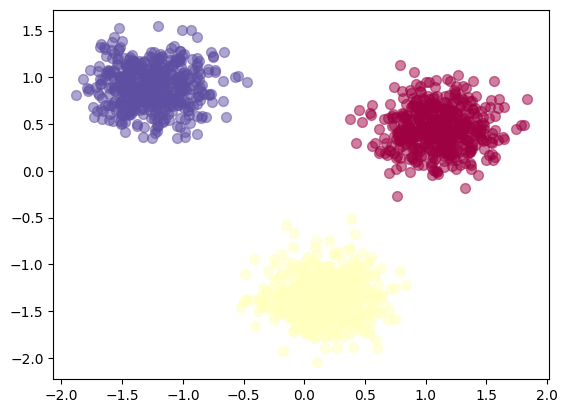

In [1]:
import numpy as np 
from sklearn.cluster import DBSCAN 
# https://stackoverflow.com/questions/65898399/no-module-named-sklearn-datasets-samples-generator
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

def createDataPoints(centroidLocation, numSamples, clusterDeviation):
  X, y = make_blobs(n_samples=numSamples, centers=centroidLocation, 
                              cluster_std=clusterDeviation)
  
  X = StandardScaler().fit_transform(X)
  return X, y

X, y = createDataPoints([[4,3], [2,-1], [-1,4]] , 1500, 0.5)

epsilon = 0.3
minimumSamples = 7
db = DBSCAN(eps=epsilon, min_samples=minimumSamples).fit(X)
labels = db.labels_
labels

core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
core_samples_mask

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters_

unique_labels = set(labels)
unique_labels

colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
colors

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'

    class_member_mask = (labels == k)

    # Plot the datapoints that are clustered
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=col, marker=u'o', alpha=0.5)

    # Plot the outliers
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=col, marker=u'o', alpha=0.5)

KMeans clusters: 3
Silhouette: 0.8084
ARI vs true labels: 1.0


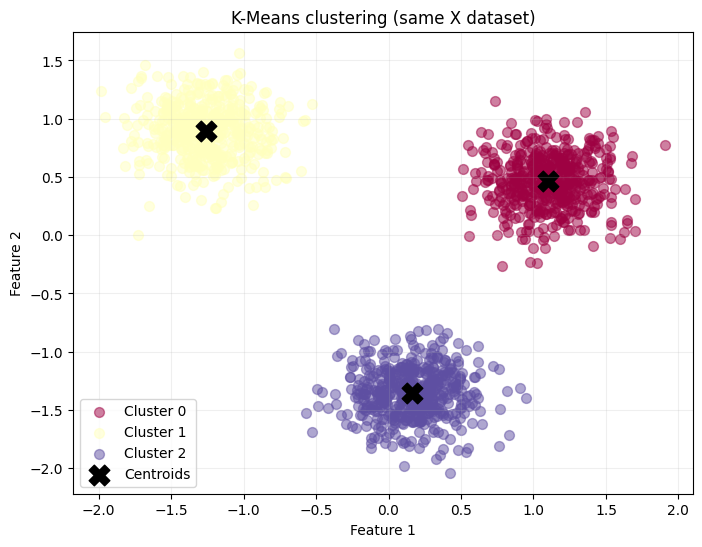

In [2]:
import numpy as np 
from sklearn.cluster import DBSCAN 
# https://stackoverflow.com/questions/65898399/no-module-named-sklearn-datasets-samples-generator
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

def createDataPoints(centroidLocation, numSamples, clusterDeviation):
  X, y = make_blobs(n_samples=numSamples, centers=centroidLocation, 
                              cluster_std=clusterDeviation)
  
  X = StandardScaler().fit_transform(X)
  return X, y

X, y = createDataPoints([[4,3], [2,-1], [-1,4]] , 1500, 0.5)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1) K-Means на том же наборе X (данные НЕ создаем заново)
k = 3  # логично, т.к. исходно 3 центра
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# 2) Метрики качества (опционально, но полезно для отчета)
sil = silhouette_score(X, kmeans_labels)
ari = adjusted_rand_score(y, kmeans_labels)  # y есть из make_blobs

print("KMeans clusters:", len(set(kmeans_labels)))
print("Silhouette:", round(sil, 4))
print("ARI vs true labels:", round(ari, 4))

# 3) Визуализация кластеров K-Means
plt.figure(figsize=(8, 6))
colors = plt.cm.Spectral(np.linspace(0, 1, k))

for cluster_id, col in zip(range(k), colors):
    cluster_points = X[kmeans_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=50, c=[col], marker='o', alpha=0.5, label=f'Cluster {cluster_id}')

# центры кластеров
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=220, marker='X', label='Centroids')

plt.title('K-Means clustering (same X dataset)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

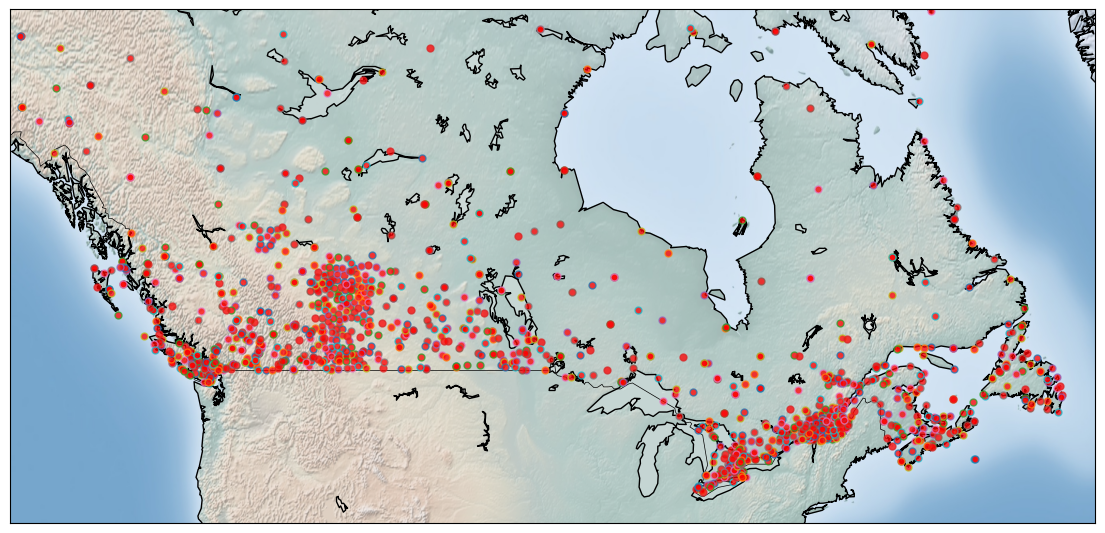

Cluster 0, Avg Temp: -5.538747553816046
Cluster 1, Avg Temp: 1.9526315789473685
Cluster 2, Avg Temp: -9.195652173913045
Cluster 3, Avg Temp: -15.300833333333333
Cluster 4, Avg Temp: -7.769047619047619
Cluster 0, Avg Temp: 6.221192052980132
Cluster 1, Avg Temp: 6.790000000000001
Cluster 2, Avg Temp: -0.49411764705882344
Cluster 3, Avg Temp: -13.87720930232558
Cluster 4, Avg Temp: -4.186274509803922
Cluster 5, Avg Temp: -16.301503759398496
Cluster 6, Avg Temp: -13.599999999999998
Cluster 7, Avg Temp: -9.753333333333334
Cluster 8, Avg Temp: -4.258333333333334


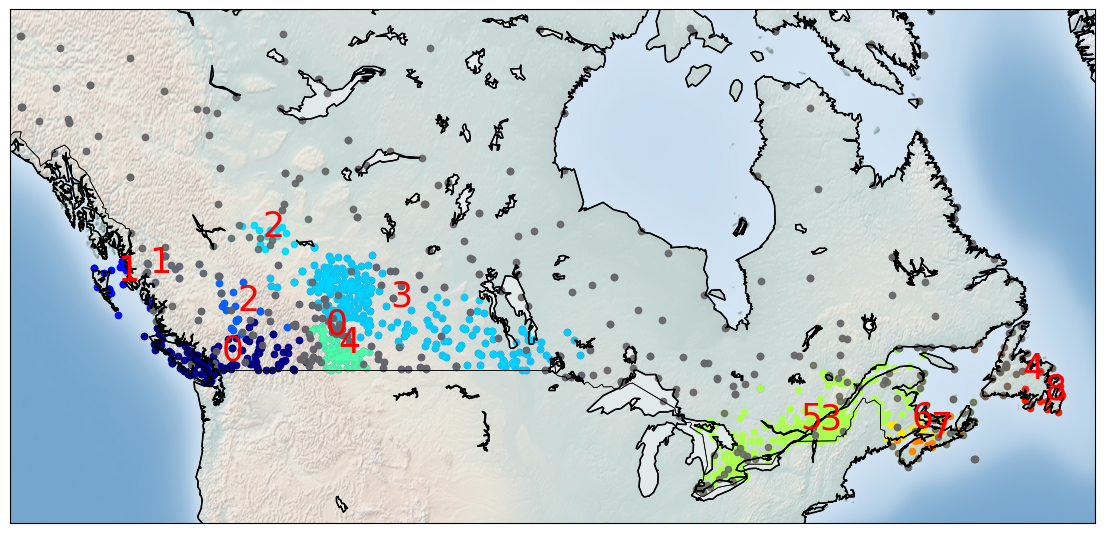

In [3]:
filename='/home/jupyter/work/data/weather-stations20140101-20141231.csv'
pdf = pd.read_csv(filename)
pdf.head(5)

pdf = pdf[pd.notnull(pdf["Tm"])]
pdf = pdf.reset_index(drop=True)
pdf.head(5)

from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from pylab import rcParams

rcParams['figure.figsize'] = (14,10)

llon=-140
ulon=-50
llat=40
ulat=65

pdf=pdf[(pdf['Long']>llon)&(pdf['Long']<ulon)&(pdf['Lat']>llat)&(pdf['Lat'] < ulat)]

my_map = Basemap(projection='merc',
            resolution = 'l', area_thresh = 1000.0,
            llcrnrlon=llon, llcrnrlat=llat,
            urcrnrlon=ulon, urcrnrlat=ulat) 

my_map.drawcoastlines()
my_map.drawcountries()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()       

xs,ys = my_map(np.asarray(pdf.Long), np.asarray(pdf.Lat))
pdf['xm']= xs.tolist()
pdf['ym'] =ys.tolist()

for index,row in pdf.iterrows():
   my_map.plot(row.xm, row.ym,markerfacecolor =([1,0,0]),  
               marker='o', markersize= 5, alpha = 0.75)
plt.show()


from sklearn.cluster import DBSCAN
import sklearn.utils
from sklearn.preprocessing import StandardScaler
sklearn.utils.check_random_state(1000)
Clus_dataSet = pdf[['xm','ym']]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

db = DBSCAN(eps=0.15, min_samples=10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
pdf["Clus_Db"]=labels

realClusterNum=len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels)) 

pdf[["Stn_Name","Tx","Tm","Clus_Db"]].head(5)


from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
rcParams['figure.figsize'] = (14,10)

my_map = Basemap(projection='merc',
            resolution = 'l', area_thresh = 1000.0,
            #min longitude (llcrnrlon) and latitude (llcrnrlat)
            llcrnrlon=llon, llcrnrlat=llat, 
            #max longitude (urcrnrlon) and latitude (urcrnrlat)
            urcrnrlon=ulon, urcrnrlat=ulat) 

my_map.drawcoastlines()
my_map.drawcountries()
#my_map.drawmapboundary()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()

colors = plt.get_cmap('jet')(np.linspace(0.0, 1.0, clusterNum))

for clust_number in set(labels):
    c=(([0.4,0.4,0.4]) if clust_number == -1 else colors[np.int64(clust_number)])
    clust_set = pdf[pdf.Clus_Db == clust_number]                    
    my_map.scatter(clust_set.xm, clust_set.ym, color =c,  
                   marker='o', s= 20, alpha = 0.85)
    if clust_number != -1:
        cenx=np.mean(clust_set.xm) 
        ceny=np.mean(clust_set.ym) 
        plt.text(cenx,ceny,str(clust_number), fontsize=25, color='red',)
        print ("Cluster "+str(clust_number)+', Avg Temp: '+ str(np.mean(clust_set.Tm)))

from sklearn.cluster import DBSCAN
import sklearn.utils
from sklearn.preprocessing import StandardScaler
sklearn.utils.check_random_state(1000)
Clus_dataSet = pdf[['xm','ym','Tx','Tm','Tn']]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

db = DBSCAN(eps=0.3, min_samples=10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
pdf["Clus_Db"]=labels

realClusterNum=len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels)) 

pdf[["Stn_Name","Tx","Tm","Clus_Db"]].head(5)


from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
rcParams['figure.figsize'] = (14,10)

my_map = Basemap(projection='merc',
            resolution = 'l', area_thresh = 1000.0,
            #min longitude (llcrnrlon) and latitude (llcrnrlat)
            llcrnrlon=llon, llcrnrlat=llat, 
            #max longitude (urcrnrlon) and latitude (urcrnrlat)
            urcrnrlon=ulon, urcrnrlat=ulat) 

my_map.drawcoastlines()
my_map.drawcountries()
#my_map.drawmapboundary()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()

colors = plt.get_cmap('jet')(np.linspace(0.0, 1.0, clusterNum))

for clust_number in set(labels):
    c=(([0.4,0.4,0.4]) if clust_number == -1 else colors[np.int64(clust_number)])
    clust_set = pdf[pdf.Clus_Db == clust_number]                    
    my_map.scatter(clust_set.xm, clust_set.ym, color =c,  
                   marker='o', s= 20, alpha = 0.85)
    if clust_number != -1:
        cenx=np.mean(clust_set.xm) 
        ceny=np.mean(clust_set.ym) 
        plt.text(cenx,ceny,str(clust_number), fontsize=25, color='red',)
        print ("Cluster "+str(clust_number)+', Avg Temp: '+ str(np.mean(clust_set.Tm)))